In [ ]:
## Read mainMNNs*.ipynb files and report the peak train, peak validation, and test accuracies of all models. 

import nbformat
import re
import numpy as np
import glob

# Regex patterns
train_val_pattern = re.compile(r"Train Accuracy: ([\d.]+)%, Validation Accuracy: ([\d.]+)%")
test_pattern = re.compile(r"Accuracy on the test set: ([\d.]+)%")
model_pattern = re.compile(r"model\s*=\s*((\w+)\s*\([^)]*\))")

# Read all mainMNNs_*.ipynb notebooks
notebook_files = sorted(glob.glob("mainMNNs*.ipynb"))

# Store results
all_results = []

for nb_path in notebook_files:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    models = {}

    code_cells = [cell for cell in nb.cells if cell.cell_type == "code"]
    i = 0
    while i < len(code_cells) - 1:
        cell_train = code_cells[i]
        cell_test = code_cells[i + 1]

        train_text = "".join(o.get("text", "") for o in cell_train.get("outputs", []) if o["output_type"] == "stream")
        test_text = "".join(o.get("text", "") for o in cell_test.get("outputs", []) if o["output_type"] == "stream")
        model_code = "".join(cell_train.get("source", ""))

        # Check if it matches the expected pattern
        train_val_matches = train_val_pattern.findall(train_text)
        test_match = test_pattern.search(test_text)
        model_match = model_pattern.search(model_code)

        if train_val_matches and test_match and model_match:
            model = model_match.group(1)
            train_accuracies = [float(t) for t, _ in train_val_matches]
            val_accuracies = [float(v) for _, v in train_val_matches]
            test_accuracy = float(test_match.group(1))

            models[model] = models.get(model, 0) + 1

            peak_train = max(train_accuracies)
            peak_val = max(val_accuracies)

            all_results.append({
                "model": model + f"_{models[model]}",
                "train": peak_train,
                "val": peak_val,
                "test": test_accuracy
            })

            i += 2  # Skip to next pair
        else:
            i += 1  # Try next cell if this wasn't a valid pair

# Group results by model, keeping separate entries for different instances
from collections import defaultdict

grouped = defaultdict(list)
for entry in all_results:
    key = entry['model']
    grouped[key].append((entry["train"], entry["val"], entry["test"]))

# Print results
for key, values in grouped.items():
    values_np = np.array(values)
    means = values_np.mean(axis=0)
    stds = values_np.std(axis=0)
    print(f"{key}: train: {means[0]:.2f} +- {stds[0]:.2f}, "
          f"validation: {means[1]:.2f} +- {stds[1]:.2f}, "
          f"test: {means[2]:.2f} +- {stds[2]:.2f}, "
          f"     latex format: {means[0]:.2f} $\pm$ {stds[0]:.2f} & {means[1]:.2f} $\pm$ {stds[1]:.2f} & {means[2]:.2f} $\pm$ {stds[2]:.2f}")


MLP()_1: train: 99.88 +- 0.04, validation: 98.16 +- 0.13, test: 98.01 +- 0.08,      latex format: 99.88 $\pm$ 0.04 & 98.16 $\pm$ 0.13 & 98.01 $\pm$ 0.08
MP()_1: train: 31.24 +- 1.51, validation: 31.65 +- 1.31, test: 31.59 +- 1.28,      latex format: 31.24 $\pm$ 1.51 & 31.65 $\pm$ 1.31 & 31.59 $\pm$ 1.28
DEP()_1: train: 76.63 +- 3.46, validation: 76.29 +- 3.21, test: 76.51 +- 3.36,      latex format: 76.63 $\pm$ 3.46 & 76.29 $\pm$ 3.21 & 76.51 $\pm$ 3.36
DEP(l=1/2)_1: train: 76.96 +- 1.13, validation: 77.08 +- 1.33, test: 77.64 +- 1.03,      latex format: 76.96 $\pm$ 1.13 & 77.08 $\pm$ 1.33 & 77.64 $\pm$ 1.03
Act_MP()_1: train: 66.17 +- 14.17, validation: 65.32 +- 14.43, test: 65.27 +- 13.97,      latex format: 66.17 $\pm$ 14.17 & 65.32 $\pm$ 14.43 & 65.27 $\pm$ 13.97
Act_DEP()_1: train: 84.51 +- 1.16, validation: 83.59 +- 1.09, test: 84.15 +- 1.03,      latex format: 84.51 $\pm$ 1.16 & 83.59 $\pm$ 1.09 & 84.15 $\pm$ 1.03
Act_DEP(l=3/4)_1: train: 94.04 +- 0.37, validation: 92.26 +- 0.53

In [ ]:
## Read mainMNNs*.ipynb files and report the finanl train, final validation, and test accuracies of all models. 

import nbformat
import re
import numpy as np
import glob

# Regex patterns
train_val_pattern = re.compile(r"Train Accuracy: ([\d.]+)%, Validation Accuracy: ([\d.]+)%")
test_pattern = re.compile(r"Accuracy on the test set: ([\d.]+)%")
model_pattern = re.compile(r"model\s*=\s*((\w+)\s*\([^)]*\))")

# Read all mainMNNs_*.ipynb notebooks
notebook_files = sorted(glob.glob("mainMNNs*.ipynb"))

# Store results
all_results = []

for nb_path in notebook_files:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    models = {}

    code_cells = [cell for cell in nb.cells if cell.cell_type == "code"]
    i = 0
    while i < len(code_cells) - 1:
        cell_train = code_cells[i]
        cell_test = code_cells[i + 1]

        train_text = "".join(o.get("text", "") for o in cell_train.get("outputs", []) if o["output_type"] == "stream")
        test_text = "".join(o.get("text", "") for o in cell_test.get("outputs", []) if o["output_type"] == "stream")
        model_code = "".join(cell_train.get("source", ""))

        # Check if it matches the expected pattern
        train_val_matches = train_val_pattern.findall(train_text)
        test_match = test_pattern.search(test_text)
        model_match = model_pattern.search(model_code)

        if train_val_matches and test_match and model_match:
            model = model_match.group(1)
            train_accuracies = [float(t) for t, _ in train_val_matches]
            val_accuracies = [float(v) for _, v in train_val_matches]
            test_accuracy = float(test_match.group(1))

            models[model] = models.get(model, 0) + 1

            final_train = train_accuracies[-1]
            final_val = val_accuracies[-1]

            all_results.append({
                "model": model + f"_{models[model]}",
                "train": final_train,
                "val": final_val,
                "test": test_accuracy
            })

            i += 2  # Skip to next pair
        else:
            i += 1  # Try next cell if this wasn't a valid pair

# Group results by model, keeping separate entries for different instances
from collections import defaultdict

grouped = defaultdict(list)
for entry in all_results:
    key = entry['model']
    grouped[key].append((entry["train"], entry["val"], entry["test"]))

# Print results
for key, values in grouped.items():
    values_np = np.array(values)
    means = values_np.mean(axis=0)
    stds = values_np.std(axis=0)
    print(f"{key}: final train: {means[0]:.2f} +- {stds[0]:.2f}, "
          f"final validation: {means[1]:.2f} +- {stds[1]:.2f}, "
          f"test: {means[2]:.2f} +- {stds[2]:.2f}")


MLP()_1: final train: 99.43 +- 0.20, final validation: 97.40 +- 0.33, test: 98.01 +- 0.08
MP()_1: final train: 28.56 +- 1.75, final validation: 28.86 +- 1.98, test: 31.59 +- 1.28
DEP()_1: final train: 75.56 +- 4.37, final validation: 75.40 +- 4.07, test: 76.51 +- 3.36
DEP(l=1/2)_1: final train: 76.77 +- 0.87, final validation: 76.81 +- 0.95, test: 77.64 +- 1.03
Act_MP()_1: final train: 66.17 +- 14.17, final validation: 65.31 +- 14.43, test: 65.27 +- 13.97
Act_DEP()_1: final train: 84.46 +- 1.12, final validation: 83.53 +- 1.14, test: 84.15 +- 1.03
Act_DEP(l=3/4)_1: final train: 94.01 +- 0.38, final validation: 92.22 +- 0.50, test: 92.29 +- 0.64
Act_DEP(l=1/2)_1: final train: 99.15 +- 0.23, final validation: 94.53 +- 0.11, test: 94.43 +- 0.26
MPM()_1: final train: 99.80 +- 0.04, final validation: 94.68 +- 0.14, test: 94.66 +- 0.13
RMPM()_1: final train: 99.99 +- 0.00, final validation: 95.56 +- 0.03, test: 95.52 +- 0.22
RMPM_Drop(dropout=0.3)_1: final train: 99.84 +- 0.03, final validat

In [ ]:
## Read mainMNNs*.ipynb files and report L2 pruning results

import nbformat
import re
import numpy as np
import glob

# Regex patterns
train_val_pattern = re.compile(r"Train Accuracy: ([\d.]+)%, Validation Accuracy: ([\d.]+)%")
test_pattern = re.compile(r"Accuracy on the test set: ([\d.]+)%")
pruning_ratio_pattern = re.compile(r"Pruning ratio: ([\d.]+)")
compression_pattern = re.compile(r"Accuracy on the test set: ([\d.]+)")
model_pattern = re.compile(r"model\s*=\s*((\w+)\s*\([^)]*\))")

# Read all mainMNNs_*.ipynb notebooks
notebook_files = sorted(glob.glob("mainMNNs*.ipynb"))

# Store results
all_results = []

for nb_path in notebook_files:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    models = {}

    code_cells = [cell for cell in nb.cells if cell.cell_type == "code"]
    i = 0
    while i + 2 < len(code_cells):
        cell_train = code_cells[i]
        cell_test = code_cells[i + 1]
        cell_compression = code_cells[i + 2]

        train_text = "".join(o.get("text", "") for o in cell_train.get("outputs", []) if o["output_type"] == "stream")
        test_text = "".join(o.get("text", "") for o in cell_test.get("outputs", []) if o["output_type"] == "stream")
        model_code = "".join(cell_train.get("source", ""))
        compression_text = "".join(o.get("text", "") for o in cell_compression.get("outputs", []) if o["output_type"] == "stream")

        # Check if it matches the expected pattern
        train_val_matches = train_val_pattern.findall(train_text)
        test_match = test_pattern.search(test_text)
        model_match = model_pattern.search(model_code)
        pruning_ratio_matches = pruning_ratio_pattern.findall(compression_text)
        compression_matches = compression_pattern.findall(compression_text)

        if train_val_matches and test_match and model_match and pruning_ratio_matches and compression_matches:
            model = model_match.group(1)
            train_accuracies = [float(t) for t, _ in train_val_matches]
            val_accuracies = [float(v) for _, v in train_val_matches]
            test_accuracy = float(test_match.group(1))
            pruning_ratios = [float(p) for p in pruning_ratio_matches]
            compression = [float(c) for c in compression_matches]

            models[model] = models.get(model, 0) + 1

            all_results.append({
                "model": model + f"_{models[model]}",
                "pruning_ratio": pruning_ratios,
                "compression": compression,
                "test": test_accuracy
            })

            i += 3  # Skip to next tuple
        else:
            i += 1  # Try next cell if this wasn't a valid tuple

# Group results by model, keeping separate entries for different instances
from collections import defaultdict

grouped = defaultdict(list)
for entry in all_results:
    key = entry['model']
    grouped[key].append((entry["pruning_ratio"], entry["compression"]))

# Print results with 2 decimal points for arrays
for key, values in grouped.items():
    values_np = np.array(values)  # Ensure flexibility in array shapes
    means = np.mean(values_np, axis=0)
    stds = np.std(values_np, axis=0)

    # Format each element in the arrays to 2 decimal places
    formatted_pruning = ", ".join(f"{x:.3f}" for x in means[0])
    formatted_compression_mean = ", ".join(f"{x:.2f}" for x in means[1])
    formatted_compression_std = ", ".join(f"{x:.2f}" for x in stds[1])

    print(f"{key}: pruning ratios: [{formatted_pruning}], "
          f"compression accuracy: [{formatted_compression_mean}] ± [{formatted_compression_std}]")


MLP()_1: pruning ratios: [0.850, 0.875, 0.900, 0.925, 0.950, 0.975], compression accuracy: [71.93, 58.52, 38.20, 17.19, 11.51, 9.88] ± [5.48, 4.63, 8.89, 3.53, 1.80, 0.25]
MPM()_1: pruning ratios: [0.850, 0.875, 0.900, 0.925, 0.950, 0.975], compression accuracy: [93.59, 93.02, 92.21, 90.88, 78.65, 64.37] ± [0.65, 0.73, 1.01, 1.01, 13.99, 10.75]
MLP()_2: pruning ratios: [0.850, 0.875, 0.900, 0.925, 0.950, 0.975], compression accuracy: [54.12, 34.46, 17.17, 13.29, 10.70, 10.27] ± [4.38, 5.50, 2.23, 2.02, 1.19, 0.19]
MPM()_2: pruning ratios: [0.850, 0.875, 0.900, 0.925, 0.950, 0.975], compression accuracy: [80.83, 79.92, 79.19, 77.53, 74.94, 57.11] ± [1.09, 1.17, 0.99, 1.74, 0.16, 4.62]


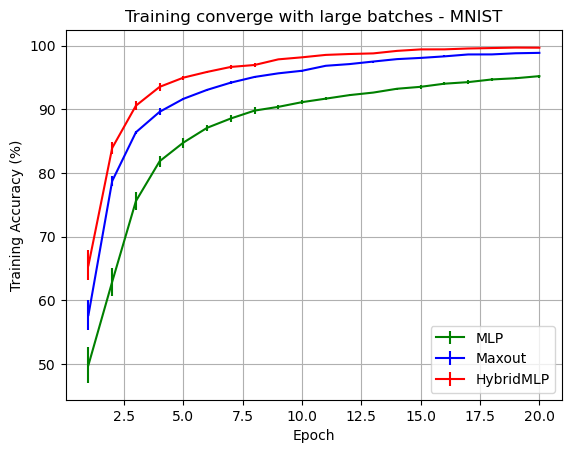

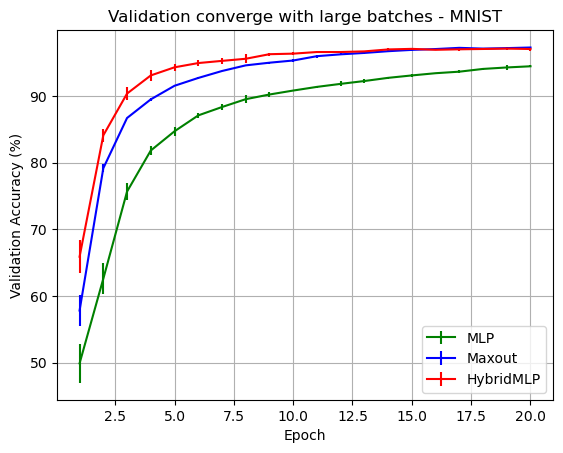

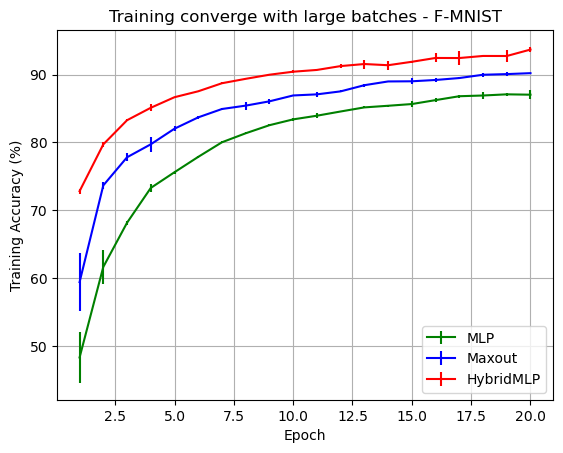

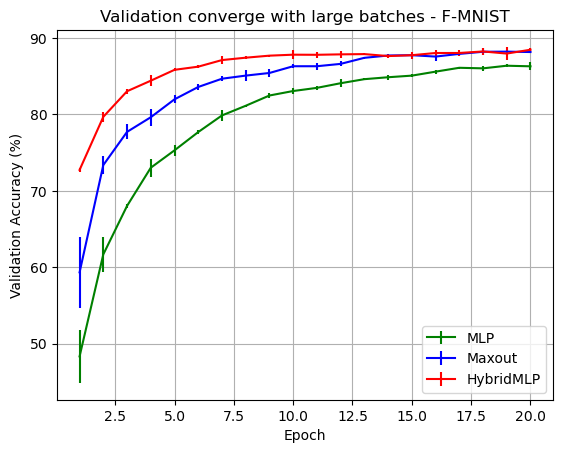

In [ ]:
import nbformat
import re
import numpy as np
import glob
import matplotlib.pyplot as plt

# Regex patterns
train_val_pattern = re.compile(r"Train Accuracy: ([\d.]+)%, Validation Accuracy: ([\d.]+)%")
model_pattern = re.compile(r"model\s*=\s*((\w+)\s*\([^)]*\))")

# Read all mainMNNs_*.ipynb notebooks
notebook_files = sorted(glob.glob("mainMNNs*.ipynb"))

# Store results
mlp_results = []
maxout_results = []
hybrid_results = []

for nb_path in notebook_files:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    mlp_models = 0
    maxout_models = 0
    hybrid_models = 0

    code_cells = [cell for cell in nb.cells if cell.cell_type == "code"]
    i = 0
    while i + 3 < len(code_cells):
        cell_mlp = code_cells[i]
        cell_maxout = code_cells[i + 1]
        cell_hybrid = code_cells[i + 2]
        cell_image = code_cells[i + 3]

        mlp_text = "".join(o.get("text", "") for o in cell_mlp.get("outputs", []) if o["output_type"] == "stream")
        maxout_text = "".join(o.get("text", "") for o in cell_maxout.get("outputs", []) if o["output_type"] == "stream")
        hybrid_text = "".join(o.get("text", "") for o in cell_hybrid.get("outputs", []) if o["output_type"] == "stream")
        model_code_mlp = "".join(cell_mlp.get("source", ""))
        model_code_maxout = "".join(cell_maxout.get("source", ""))
        model_code_hybrid = "".join(cell_hybrid.get("source", ""))

        # Check if it matches the expected pattern
        mlp_matches = train_val_pattern.findall(mlp_text)
        maxout_matches = train_val_pattern.findall(maxout_text)
        hybrid_matches = train_val_pattern.findall(hybrid_text)
        model_mlp_match = model_pattern.search(model_code_mlp)
        model_maxout_match = model_pattern.search(model_code_maxout)
        model_hybrid_match = model_pattern.search(model_code_hybrid)

        if mlp_matches and maxout_matches and hybrid_matches and model_mlp_match and "MLP" in model_mlp_match.group(1) and model_maxout_match and "Maxout" in model_maxout_match.group(1) and model_hybrid_match and "Hybrid" in model_hybrid_match.group(1):
            mlp_train_accuracies = [float(t) for t, _ in mlp_matches]
            mlp_val_accuracies = [float(v) for _, v in mlp_matches]
            maxout_train_accuracies = [float(t) for t, _ in maxout_matches]
            maxout_val_accuracies = [float(v) for _, v in maxout_matches]
            hybrid_train_accuracies = [float(t) for t, _ in hybrid_matches]
            hybrid_val_accuracies = [float(v) for _, v in hybrid_matches]

            mlp_models += 1
            mlp_results.append({
                "model" : mlp_models,
                "train": mlp_train_accuracies,
                "validation": mlp_val_accuracies,
            })

            maxout_models += 1
            maxout_results.append({
                "model" : maxout_models, 
                "train": maxout_train_accuracies,
                "validation": maxout_val_accuracies,
            })

            hybrid_models += 1
            hybrid_results.append({
                "model" : hybrid_models, 
                "train": hybrid_train_accuracies,
                "validation": hybrid_val_accuracies,
            })

            i += 4  # Skip to next tuple
        else:
            i += 1  # Try next cell if this wasn't a valid tuple

# Group results by model, keeping separate entries for different instances
from collections import defaultdict

mlp_grouped = defaultdict(list)
for entry in mlp_results:
    key = entry['model']
    mlp_grouped[key].append((entry["train"], entry["validation"]))

maxout_grouped = defaultdict(list)
for entry in maxout_results:
    key = entry['model']
    maxout_grouped[key].append((entry["train"], entry["validation"]))

hybrid_grouped = defaultdict(list)
for entry in hybrid_results:
    key = entry['model']
    hybrid_grouped[key].append((entry["train"], entry["validation"]))    

# Print results with 2 decimal points for arrays
for (key, mlp_values), (_, maxout_values), (_, hybrid_values) in zip(mlp_grouped.items(), maxout_grouped.items(), hybrid_grouped.items()):
    mlp_values_np = np.array(mlp_values) 
    mlp_means = np.mean(mlp_values_np, axis=0)
    mlp_stds = np.std(mlp_values_np, axis=0)

    maxout_values_np = np.array(maxout_values)
    maxout_means = np.mean(maxout_values_np, axis=0)
    maxout_stds = np.std(maxout_values_np, axis=0)

    hybrid_values_np = np.array(hybrid_values)
    hybrid_means = np.mean(hybrid_values_np, axis=0)
    hybrid_stds = np.std(hybrid_values_np, axis=0)

    plt.figure()
    plt.errorbar(np.arange(1,21), mlp_means[0], mlp_stds[0], color='green', label='MLP')
    plt.errorbar(np.arange(1,21), maxout_means[0], maxout_stds[0], color='blue', label='Maxout')
    plt.errorbar(np.arange(1,21), hybrid_means[0], hybrid_stds[0], color='red', label='HybridMLP')
    plt.legend()
    plt.grid()
    plt.title(f'Training converge with large batches - {"MNIST" if key == 1 else "F-MNIST"}')
    plt.xlabel('Epoch')
    plt.ylabel('Training Accuracy (%)')
    plt.savefig(f"training_convergence_{'' if key == 1 else 'fashion_'}mnist_final.pdf", format='pdf', dpi=1000)
    plt.show()

    plt.figure()
    plt.errorbar(np.arange(1,21), mlp_means[1], mlp_stds[1], color='green', label='MLP')
    plt.errorbar(np.arange(1,21), maxout_means[1], maxout_stds[1], color='blue', label='Maxout')
    plt.errorbar(np.arange(1,21), hybrid_means[1], hybrid_stds[1], color='red', label='HybridMLP')
    plt.legend()
    plt.grid()
    plt.title(f'Validation converge with large batches - {"MNIST" if key == 1 else "F-MNIST"}')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.savefig(f"validation_convergence_{'' if key == 1 else 'fashion_'}mnist_final.pdf", format='pdf', dpi=1000)
    plt.show()


In [ ]:
## Read resnet_20_experiments*.ipynb files and report the peak train, peak validation, and test accuracies of all models. 

import nbformat
import re
import numpy as np
import glob

# Regex patterns
train_val_pattern = re.compile(r"Train Accuracy: ([\d.]+)%, Validation Accuracy: ([\d.]+)%")
test_pattern = re.compile(r"Accuracy on the test set: ([\d.]+)%")
model_pattern = re.compile(r"model\s*=\s*((\w+)\s*\([^)]*\))")

# Read all resnet_20_experiments*.ipynb notebooks
notebook_files = sorted(glob.glob("resnet_20_experiments*.ipynb"))

# Store results
all_results = []

for nb_path in notebook_files:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    models = {}

    code_cells = [cell for cell in nb.cells if cell.cell_type == "code"]
    i = 0
    while i < len(code_cells) - 1:
        cell_train = code_cells[i]
        cell_test = code_cells[i + 1]

        train_text = "".join(o.get("text", "") for o in cell_train.get("outputs", []) if o["output_type"] == "stream")
        test_text = "".join(o.get("text", "") for o in cell_test.get("outputs", []) if o["output_type"] == "stream")
        model_code = "".join(cell_train.get("source", ""))

        # Check if it matches the expected pattern
        train_val_matches = train_val_pattern.findall(train_text)
        test_match = test_pattern.search(test_text)
        model_match = model_pattern.search(model_code)

        if train_val_matches and test_match and model_match:
            model = model_match.group(1)
            train_accuracies = [float(t) for t, _ in train_val_matches]
            val_accuracies = [float(v) for _, v in train_val_matches]
            test_accuracy = float(test_match.group(1))

            models[model] = models.get(model, 0) + 1

            peak_train = max(train_accuracies)
            peak_val = max(val_accuracies)

            all_results.append({
                "model": model + f"_{models[model]}",
                "train": peak_train,
                "val": peak_val,
                "test": test_accuracy
            })

            i += 2  # Skip to next pair
        else:
            i += 1  # Try next cell if this wasn't a valid pair

# Group results by model, keeping separate entries for different instances
from collections import defaultdict

grouped = defaultdict(list)
for entry in all_results:
    key = entry['model']
    grouped[key].append((entry["train"], entry["val"], entry["test"]))

# Print results
for key, values in grouped.items():
    values_np = np.array(values)
    means = values_np.mean(axis=0)
    stds = values_np.std(axis=0)
    print(f"{key}: train: {means[0]:.2f} +- {stds[0]:.2f}, "
          f"validation: {means[1]:.2f} +- {stds[1]:.2f}, "
          f"test: {means[2]:.2f} +- {stds[2]:.2f}, "
          f"     latex format: {means[0]:.2f} $\pm$ {stds[0]:.2f} & {means[1]:.2f} $\pm$ {stds[1]:.2f} & {means[2]:.2f} $\pm$ {stds[2]:.2f}")


ResNet20(in_channels=3)_1: train: 99.10 +- 0.11, validation: 82.16 +- 0.40, test: 81.74 +- 0.27,      latex format: 99.10 $\pm$ 0.11 & 82.16 $\pm$ 0.40 & 81.74 $\pm$ 0.27
MPM_ResNet20(in_channels=3)_1: train: 95.34 +- 0.80, validation: 62.30 +- 0.37, test: 62.14 +- 0.22,      latex format: 95.34 $\pm$ 0.80 & 62.30 $\pm$ 0.37 & 62.14 $\pm$ 0.22
ResNet20(in_channels=1)_1: train: 99.69 +- 0.05, validation: 92.98 +- 0.14, test: 92.42 +- 0.04,      latex format: 99.69 $\pm$ 0.05 & 92.98 $\pm$ 0.14 & 92.42 $\pm$ 0.04
MPM_ResNet20(in_channels=1)_1: train: 96.30 +- 0.22, validation: 90.08 +- 0.17, test: 89.38 +- 0.26,      latex format: 96.30 $\pm$ 0.22 & 90.08 $\pm$ 0.17 & 89.38 $\pm$ 0.26


In [ ]:
## Read resnet_20_experiments*.ipynb files and report the final train, final validation, and test accuracies of all models. 

import nbformat
import re
import numpy as np
import glob

# Regex patterns
train_val_pattern = re.compile(r"Train Accuracy: ([\d.]+)%, Validation Accuracy: ([\d.]+)%")
test_pattern = re.compile(r"Accuracy on the test set: ([\d.]+)%")
model_pattern = re.compile(r"model\s*=\s*((\w+)\s*\([^)]*\))")

# Read all mainMNNs_*.ipynb notebooks
notebook_files = sorted(glob.glob("resnet_20_experiments*.ipynb"))

# Store results
all_results = []

for nb_path in notebook_files:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    models = {}

    code_cells = [cell for cell in nb.cells if cell.cell_type == "code"]
    i = 0
    while i < len(code_cells) - 1:
        cell_train = code_cells[i]
        cell_test = code_cells[i + 1]

        train_text = "".join(o.get("text", "") for o in cell_train.get("outputs", []) if o["output_type"] == "stream")
        test_text = "".join(o.get("text", "") for o in cell_test.get("outputs", []) if o["output_type"] == "stream")
        model_code = "".join(cell_train.get("source", ""))

        # Check if it matches the expected pattern
        train_val_matches = train_val_pattern.findall(train_text)
        test_match = test_pattern.search(test_text)
        model_match = model_pattern.search(model_code)

        if train_val_matches and test_match and model_match:
            model = model_match.group(1)
            train_accuracies = [float(t) for t, _ in train_val_matches]
            val_accuracies = [float(v) for _, v in train_val_matches]
            test_accuracy = float(test_match.group(1))

            models[model] = models.get(model, 0) + 1

            final_train = train_accuracies[-1]
            final_val = val_accuracies[-1]

            all_results.append({
                "model": model + f"_{models[model]}",
                "train": final_train,
                "val": final_val,
                "test": test_accuracy
            })

            i += 2  # Skip to next pair
        else:
            i += 1  # Try next cell if this wasn't a valid pair

# Group results by model, keeping separate entries for different instances
from collections import defaultdict

grouped = defaultdict(list)
for entry in all_results:
    key = entry['model']
    grouped[key].append((entry["train"], entry["val"], entry["test"]))

# Print results
for key, values in grouped.items():
    values_np = np.array(values)
    means = values_np.mean(axis=0)
    stds = values_np.std(axis=0)
    print(f"{key}: final train: {means[0]:.2f} +- {stds[0]:.2f}, "
          f"final validation: {means[1]:.2f} +- {stds[1]:.2f}, "
          f"test: {means[2]:.2f} +- {stds[2]:.2f}")


ResNet20(in_channels=3)_1: final train: 97.89 +- 0.38, final validation: 80.40 +- 0.48, test: 81.74 +- 0.27
MPM_ResNet20(in_channels=3)_1: final train: 93.33 +- 0.67, final validation: 58.59 +- 0.97, test: 62.14 +- 0.22
ResNet20(in_channels=1)_1: final train: 99.61 +- 0.11, final validation: 92.52 +- 0.21, test: 92.42 +- 0.04
MPM_ResNet20(in_channels=1)_1: final train: 96.23 +- 0.32, final validation: 89.86 +- 0.11, test: 89.38 +- 0.26
